# GĐ 3 — Nâng cấp lên MNL (Multinomial Logit)

## Vì sao cần

Logit nhị phân ở `00_TONG_HOP` buộc ta phải **tự tay** phân biệt hai loại elasticity:

| | Nghĩa | Giá trị dùng |
|---|---|---|
| `ε_market` | **Cả thị trường** cùng tăng giá | −0,3 … −0,7 |
| `ε_firm` | **Chỉ mình** tăng giá, đối thủ đứng yên | −1,2 … −3,0 |

Đây chính là chỗ phiên bản đầu tiên đã sai (dùng nhầm `ε_market` cho bài toán cạnh tranh trực tiếp).
MNL **không thể sai chỗ này** vì nó mô hình đúng tập lựa chọn thật, và **cả hai elasticity suy ra
từ MỘT tham số `β` duy nhất**.

## Mô hình

Khách đứng trước **3 lựa chọn**:

```
  0 : không đi  (outside option — đi xe máy, bus, ở nhà…)
  1 : đi với MÌNH        giá p₁
  2 : đi với ĐỐI THỦ     giá p₂
```

Hàm hữu dụng (dạng log-giá ⇒ elasticity hằng số quanh điểm cân bằng):

$$V_0 = \alpha_0 \qquad V_1 = \alpha_1 - \beta \ln p_1 \qquad V_2 = \alpha_2 - \beta \ln p_2$$

$$s_i \;=\; \frac{e^{V_i}}{e^{V_0} + e^{V_1} + e^{V_2}}$$

## Hai elasticity từ MỘT `β` — đây là điểm mấu chốt

Đạo hàm trực tiếp từ công thức MNL:

$$\boxed{\;\varepsilon_{\text{firm}} = -\beta\,(1 - s_1)\qquad\qquad
\varepsilon_{\text{market}} = -\beta\, s_0\;}$$

Suy ra **tỷ số** giữa hai elasticity **không phụ thuộc `β`**:

$$R \;=\; \frac{\varepsilon_{\text{firm}}}{\varepsilon_{\text{market}}}
\;=\; \frac{1 - s_1}{s_0}$$

Đây là thứ mở khoá **GĐ 2.2**: từ `R` (biết từ 2 dải elasticity đã giả định) ta **suy ngược ra
`s₀`** — tỷ lệ khách xem giá rồi không đi. Nếu `s₀` ra ngoài khoảng hợp lý [5%; 30%] thì giả định
elasticity sai và phải quay lại GĐ 1.

⚠️ **Vẫn không có nhãn accept/reject.** MNL ở đây là **hiệu chỉnh** (calibration), không phải
**ước lượng** (estimation) — không có `.fit()`, không có dữ liệu lựa chọn để khớp.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ── Gia dinh (giu NGUYEN nhu cac notebook truoc de so sanh duoc) ──
EPS_FIRM   = -2.0
EPS_MARKET = -0.5
EPS_FIRM_DAI   = [-1.2, -2.0, -3.0]
EPS_MARKET_DAI = [-0.3, -0.5, -0.7]
THI_PHAN = 0.50          # thi phan cua MINH trong so nguoi CO di xe cong nghe

print(f"eps_firm   = {EPS_FIRM}    (chi minh doi gia)")
print(f"eps_market = {EPS_MARKET}   (ca thi truong doi gia)")
print(f"R = eps_firm/eps_market = {EPS_FIRM/EPS_MARKET:.2f}")

eps_firm   = -2.0    (chi minh doi gia)
eps_market = -0.5   (ca thi truong doi gia)
R = eps_firm/eps_market = 4.00


## 1. GĐ 2.2 — Suy ngược `s₀` (tỷ lệ khách không đi)

Từ `s₁ = m·(1 − s₀)` với `m` = thị phần của mình trong nhóm **có đi**:

$$R = \frac{1 - m(1-s_0)}{s_0} \quad\Longrightarrow\quad
\boxed{\;s_0 = \frac{1-m}{R-m}\;}$$

Đây là **kiểm tra thật** — `s₀` là đại lượng vận hành đo được, nên nếu công thức nhả ra con số
vô lý (âm, hoặc >50%) thì giả định elasticity hỏng.

In [2]:
def s0_tu_R(R, m=THI_PHAN):
    """Suy nguoc ty le KHONG DI tu ty so hai elasticity."""
    return (1 - m) / (R - m)


rows = []
for ef in EPS_FIRM_DAI:
    for em in EPS_MARKET_DAI:
        R = ef / em
        s0 = s0_tu_R(R)
        dat = "✅" if 0.05 <= s0 <= 0.30 else ("❌ ngoài [5%,30%]" if s0 > 0 else "❌ ÂM - vô nghĩa")
        rows.append({"ε_firm": ef, "ε_market": em, "R": round(R, 2),
                     "s₀ suy ra": f"{s0:.1%}" if s0 > 0 else f"{s0:.1%}",
                     "hợp lý?": dat})
bang_s0 = pd.DataFrame(rows)
print("BANG 1A — GD 2.2: suy nguoc s0 (thi phan minh = 50%)")
display(bang_s0)

n_dat = (bang_s0["hợp lý?"] == "✅").sum()
print(f"\n=> {n_dat}/{len(bang_s0)} to hop cho s0 nam trong khoang hop ly [5%, 30%]")

hong = bang_s0[bang_s0["hợp lý?"] != "✅"]
if len(hong):
    print("\n⚠️  TO HOP KHONG NHAT QUAN — khong duoc dung dong thoi:")
    for _, r in hong.iterrows():
        print(f"    eps_firm={r['ε_firm']} & eps_market={r['ε_market']}  ->  s0={r['s₀ suy ra']}")
    print("    Ly do: |eps_firm| qua NHO so voi |eps_market| (R thap) => MNL phai day s0 len cao")
    print("           moi khop duoc ca hai, den muc vo ly.")
    print("    => Day chinh la gia tri cua MNL: no BAT duoc cap gia dinh mau thuan")
    print("       ma logit nhi phan khong the phat hien.")

print("\nDo nhay theo THI PHAN (voi eps_firm=-2.0, eps_market=-0.5, R=4.0):")
for m in [0.20, 0.30, 0.50, 0.70, 0.80]:
    s0 = s0_tu_R(4.0, m)
    print(f"  thi phan {m:.0%}  ->  s0 = {s0:6.1%}  {'OK' if 0.05<=s0<=0.30 else 'NGOAI KHOANG'}")

BANG 1A — GD 2.2: suy nguoc s0 (thi phan minh = 50%)


,ε_firm,ε_market,R,s₀ suy ra,hợp lý?
0,-1.2,-0.3,4.00,14.3%,✅
1,-1.2,-0.5,2.40,26.3%,✅
2,-1.2,-0.7,1.71,41.2%,"❌ ngoài [5%,30%]"
3,-2.0,-0.3,6.67,8.1%,✅
4,-2.0,-0.5,4.00,14.3%,✅
5,-2.0,-0.7,2.86,21.2%,✅
6,-3.0,-0.3,10.00,5.3%,✅
7,-3.0,-0.5,6.00,9.1%,✅
8,-3.0,-0.7,4.29,13.2%,✅



=> 8/9 to hop cho s0 nam trong khoang hop ly [5%, 30%]

⚠️  TO HOP KHONG NHAT QUAN — khong duoc dung dong thoi:
    eps_firm=-1.2 & eps_market=-0.7  ->  s0=41.2%
    Ly do: |eps_firm| qua NHO so voi |eps_market| (R thap) => MNL phai day s0 len cao
           moi khop duoc ca hai, den muc vo ly.
    => Day chinh la gia tri cua MNL: no BAT duoc cap gia dinh mau thuan
       ma logit nhi phan khong the phat hien.

Do nhay theo THI PHAN (voi eps_firm=-2.0, eps_market=-0.5, R=4.0):
  thi phan 20%  ->  s0 =  21.1%  OK
  thi phan 30%  ->  s0 =  18.9%  OK
  thi phan 50%  ->  s0 =  14.3%  OK
  thi phan 70%  ->  s0 =   9.1%  OK
  thi phan 80%  ->  s0 =   6.2%  OK


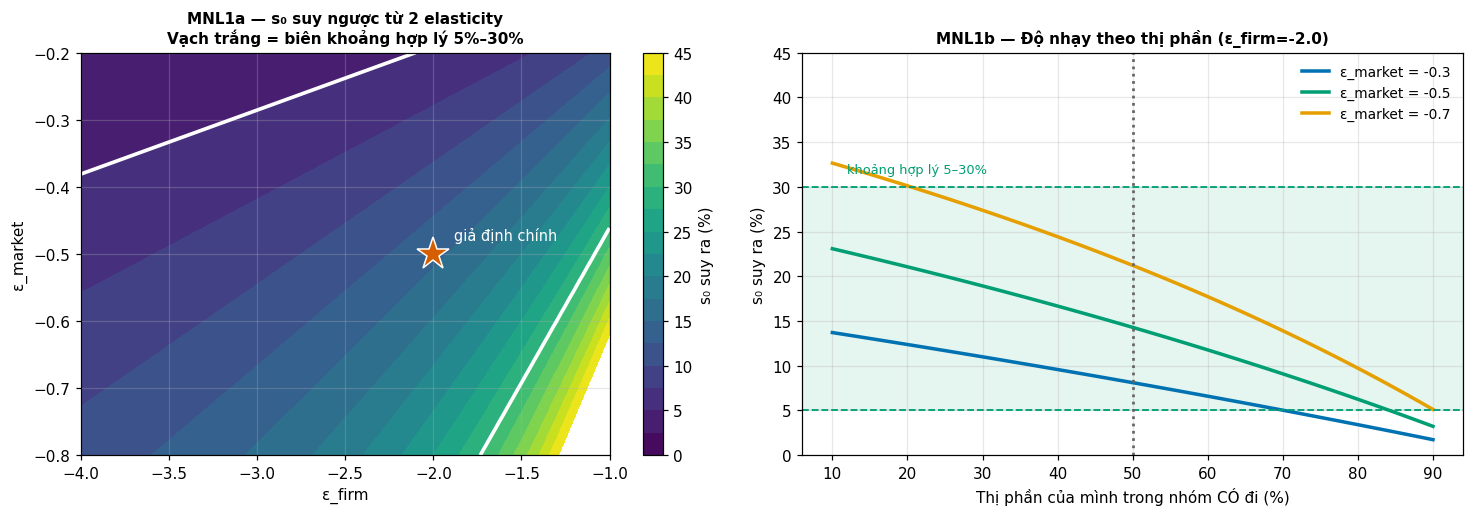

In [3]:
# ═════════ HINH MNL1 — ban do s0 ═════════
ef_grid = np.linspace(-4.0, -1.0, 61)
em_grid = np.linspace(-0.8, -0.2, 61)
Z = np.zeros((len(em_grid), len(ef_grid)))
for i, em in enumerate(em_grid):
    for j, ef in enumerate(ef_grid):
        s0 = s0_tu_R(ef / em)
        Z[i, j] = s0 if 0 < s0 < 1 else np.nan

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))

cf = ax[0].contourf(ef_grid, em_grid, Z*100, levels=np.linspace(0, 45, 19), cmap="viridis")
ax[0].contour(ef_grid, em_grid, Z*100, levels=[5, 30], colors="w", linewidths=2.4)
plt.colorbar(cf, ax=ax[0], label="s₀ suy ra (%)")
ax[0].plot(EPS_FIRM, EPS_MARKET, "*", color=RED, ms=22, markeredgecolor="w")
ax[0].text(EPS_FIRM+0.12, EPS_MARKET+0.02, "giả định chính", color="w", fontsize=9.5)
ax[0].set_xlabel("ε_firm"); ax[0].set_ylabel("ε_market")
ax[0].set_title("MNL1a — s₀ suy ngược từ 2 elasticity\nVạch trắng = biên khoảng hợp lý 5%–30%",
                fontweight="bold", fontsize=10)

ms = np.linspace(0.10, 0.90, 81)
for em, col in zip(EPS_MARKET_DAI, [BLUE, GREEN, ORANGE]):
    ys = [s0_tu_R(EPS_FIRM/em, m)*100 for m in ms]
    ax[1].plot(ms*100, ys, lw=2.3, color=col, label=f"ε_market = {em}")
ax[1].axhspan(5, 30, color=GREEN, alpha=.10)
ax[1].axhline(5, color=GREEN, ls="--", lw=1.2)
ax[1].axhline(30, color=GREEN, ls="--", lw=1.2)
ax[1].text(12, 31.5, "khoảng hợp lý 5–30%", fontsize=8.5, color=GREEN)
ax[1].axvline(THI_PHAN*100, color=MUT, ls=":", lw=1.8)
ax[1].set_xlabel("Thị phần của mình trong nhóm CÓ đi (%)")
ax[1].set_ylabel("s₀ suy ra (%)"); ax[1].set_ylim(0, 45)
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title(f"MNL1b — Độ nhạy theo thị phần (ε_firm={EPS_FIRM})",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MNL1_suy_nguoc_s0.png"); plt.show()

## 2. Hiệu chỉnh MNL đầy đủ

Đã có `s₀`, ta chốt được toàn bộ tham số:

| Bước | Công thức |
|---|---|
| `s₀` | `(1−m)/(R−m)` |
| `s₁`, `s₂` | `m(1−s₀)`, `(1−m)(1−s₀)` |
| `β` | `−ε_market / s₀` |

Sau đó khi **chỉ mình** đổi giá theo tỷ lệ `r` (đối thủ đứng yên):

$$s_1(r) \;=\; \frac{s_1^{(0)}\, r^{-\beta}}{s_0^{(0)} + s_1^{(0)} r^{-\beta} + s_2^{(0)}}$$

In [4]:
class MNL:
    """MNL 3 lua chon, hieu chinh tu (eps_firm, eps_market, thi_phan)."""

    def __init__(self, eps_firm=EPS_FIRM, eps_market=EPS_MARKET, m=THI_PHAN):
        R = eps_firm / eps_market
        self.s0 = (1 - m) / (R - m)
        if not (0 < self.s0 < 1):
            raise ValueError(f"s0 = {self.s0:.3f} vo nghia — gia dinh elasticity hong")
        self.s1 = m * (1 - self.s0)
        self.s2 = (1 - m) * (1 - self.s0)
        self.beta = -eps_market / self.s0
        self.eps_firm = eps_firm
        self.eps_market = eps_market
        self.m = m

    def share(self, r, dich_WTP=0.0):
        """Thi phan cua MINH khi minh bao gia = r x gia doi thu."""
        r = np.asarray(r, dtype=float) / (1 + dich_WTP)
        w = self.s1 * r ** (-self.beta)
        return w / (self.s0 + w + self.s2)

    def kiem_tra(self):
        """Kiem chung lai 2 elasticity tu dao ham SO — phai khop cong thuc giai tich."""
        h = 1e-5
        # firm: chi p1 doi
        d_firm = (np.log(self.share(1+h)) - np.log(self.share(1-h))) / (np.log(1+h)-np.log(1-h))
        # market: ca 2 gia doi -> Q = 1 - s0, ma s0 phu thuoc muc gia chung
        def Q(delta):
            w1 = self.s1 * np.exp(-self.beta*delta)
            w2 = self.s2 * np.exp(-self.beta*delta)
            return (w1 + w2) / (self.s0 + w1 + w2)
        d_mkt = (np.log(Q(h)) - np.log(Q(-h))) / (2*h)
        return d_firm, d_mkt


mnl = MNL()
print("=" * 66)
print("THAM SO MNL DA HIEU CHINH")
print("=" * 66)
print(f"  s0 (khong di)      : {mnl.s0:.4f}  ({mnl.s0:.1%})")
print(f"  s1 (minh)          : {mnl.s1:.4f}  ({mnl.s1:.1%})")
print(f"  s2 (doi thu)       : {mnl.s2:.4f}  ({mnl.s2:.1%})")
print(f"  beta               : {mnl.beta:.4f}")
print(f"  Tong               : {mnl.s0+mnl.s1+mnl.s2:.6f}")

d_firm, d_mkt = mnl.kiem_tra()
print()
print("KIEM CHUNG dao ham SO vs cong thuc GIAI TICH:")
print(f"  eps_firm   : muc tieu {mnl.eps_firm:7.4f} | dao ham so {d_firm:7.4f} | "
      f"giai tich {-mnl.beta*(1-mnl.s1):7.4f}")
print(f"  eps_market : muc tieu {mnl.eps_market:7.4f} | dao ham so {d_mkt:7.4f} | "
      f"giai tich {-mnl.beta*mnl.s0:7.4f}")
assert abs(d_firm - mnl.eps_firm) < 1e-3, "eps_firm khong khop!"
assert abs(d_mkt - mnl.eps_market) < 1e-3, "eps_market khong khop!"
print("\n  ✅ CA HAI elasticity deu tai tao dung tu MOT beta duy nhat.")

THAM SO MNL DA HIEU CHINH
  s0 (khong di)      : 0.1429  (14.3%)
  s1 (minh)          : 0.4286  (42.9%)
  s2 (doi thu)       : 0.4286  (42.9%)
  beta               : 3.5000
  Tong               : 1.000000

KIEM CHUNG dao ham SO vs cong thuc GIAI TICH:
  eps_firm   : muc tieu -2.0000 | dao ham so -2.0000 | giai tich -2.0000
  eps_market : muc tieu -0.5000 | dao ham so -0.5000 | giai tich -0.5000

  ✅ CA HAI elasticity deu tai tao dung tu MOT beta duy nhat.


## 3. GĐ 3.5 — MNL có cho kết quả khác logit nhị phân không?

Đây là kiểm tra quan trọng nhất. Nếu MNL cho kết quả **rất khác**, nghĩa là logit nhị phân ở
`00_TONG_HOP` đã sai và mọi kết luận phải viết lại. Nếu **khớp**, ta có thêm một bằng chứng độc lập.

So sánh theo **% thay đổi tương đối** — đúng cách trình bày đã chốt.

In [5]:
P0_BIN = 0.50


def logit_nhi_phan(r, eps=EPS_FIRM, P0=P0_BIN):
    b = eps / (1 - P0); a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * np.log(r))))


MOC = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]
goc_bin = logit_nhi_phan(1.0)
goc_mnl = mnl.share(1.0)

rows = []
for p in MOC:
    r = 1 + p
    tdoi_bin = logit_nhi_phan(r) / goc_bin - 1
    tdoi_mnl = mnl.share(r) / goc_mnl - 1
    rows.append({
        "đổi giá": f"{p:+.0%}",
        "logit nhị phân": f"{tdoi_bin:+.1%}",
        "MNL": f"{tdoi_mnl:+.1%}",
        "chênh (điểm %)": round((tdoi_mnl - tdoi_bin) * 100, 2),
    })
bang_ss = pd.DataFrame(rows)
print("BANG 3A — % THAY DOI TUONG DOI cua kha nang chap nhan")
print(f"(logit nhi phan: P0={P0_BIN} | MNL: s1={mnl.s1:.1%}, s0={mnl.s0:.1%})")
display(bang_ss)

chenh_max = bang_ss["chênh (điểm %)"].abs().max()
print(f"\nChenh lech LON NHAT giua 2 mo hinh: {chenh_max:.2f} diem %")
if chenh_max < 5:
    print("=> KHOP. Ket luan cua 00_TONG_HOP KHONG phai viet lai.")
    print("   MNL la bang chung DOC LAP cung cho ket qua tuong tu.")
else:
    print("=> LECH DANG KE — phai xem lai logit nhi phan.")

BANG 3A — % THAY DOI TUONG DOI cua kha nang chap nhan
(logit nhi phan: P0=0.5 | MNL: s1=42.9%, s0=14.3%)


,đổi giá,logit nhị phân,MNL,chênh (điểm %)
0,-20%,+41.9%,+44.9%,2.99
1,-10%,+20.8%,+21.4%,0.63
2,-5%,+10.2%,+10.4%,0.14
3,+0%,+0.0%,+0.0%,0.00
4,+5%,-9.7%,-9.6%,0.11
5,+10%,-18.8%,-18.5%,0.38
6,+20%,-34.9%,-33.8%,1.14



Chenh lech LON NHAT giua 2 mo hinh: 2.99 diem %
=> KHOP. Ket luan cua 00_TONG_HOP KHONG phai viet lai.
   MNL la bang chung DOC LAP cung cho ket qua tuong tu.


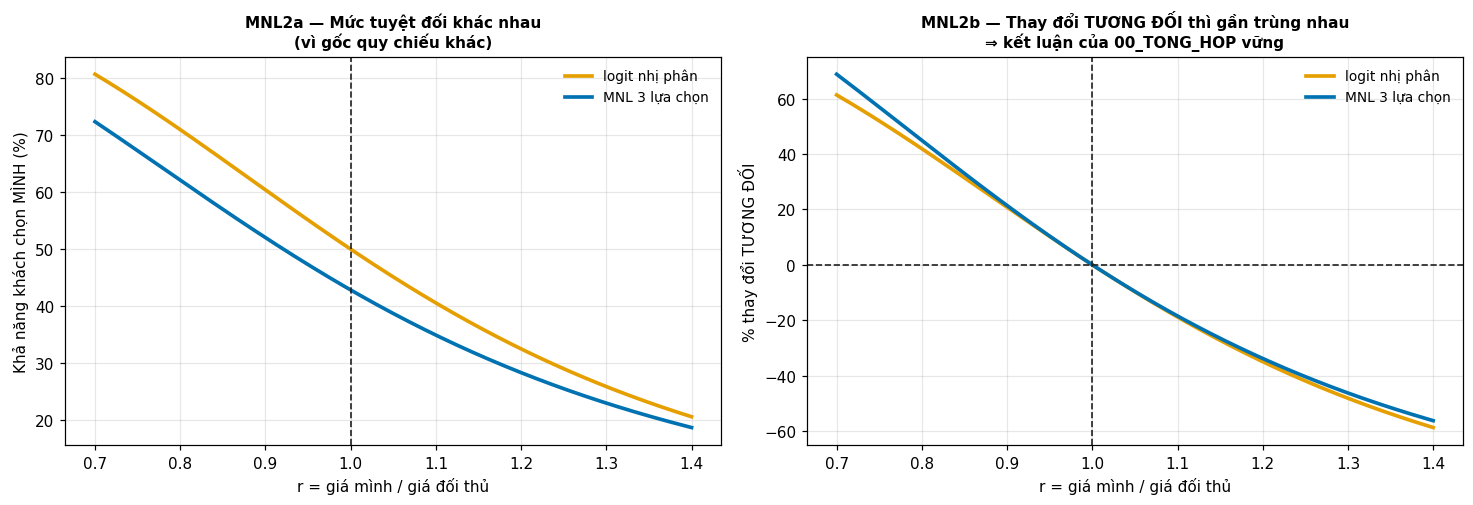

In [6]:
# ═════════ HINH MNL2 — MNL vs logit nhi phan ═════════
rr = np.linspace(0.70, 1.40, 300)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))

ax[0].plot(rr, logit_nhi_phan(rr)*100, lw=2.4, color=ORANGE, label="logit nhị phân")
ax[0].plot(rr, mnl.share(rr)*100, lw=2.4, color=BLUE, label="MNL 3 lựa chọn")
ax[0].axvline(1.0, color="#222", ls="--", lw=1.1)
ax[0].set_xlabel("r = giá mình / giá đối thủ")
ax[0].set_ylabel("Khả năng khách chọn MÌNH (%)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("MNL2a — Mức tuyệt đối khác nhau\n(vì gốc quy chiếu khác)",
                fontweight="bold", fontsize=10)

ax[1].plot(rr, (logit_nhi_phan(rr)/goc_bin - 1)*100, lw=2.4, color=ORANGE,
           label="logit nhị phân")
ax[1].plot(rr, (mnl.share(rr)/goc_mnl - 1)*100, lw=2.4, color=BLUE, label="MNL 3 lựa chọn")
ax[1].axvline(1.0, color="#222", ls="--", lw=1.1)
ax[1].axhline(0, color="#222", ls="--", lw=1.1)
ax[1].set_xlabel("r = giá mình / giá đối thủ")
ax[1].set_ylabel("% thay đổi TƯƠNG ĐỐI")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("MNL2b — Thay đổi TƯƠNG ĐỐI thì gần trùng nhau\n"
                "⇒ kết luận của 00_TONG_HOP vững", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MNL2_mnl_vs_logit.png"); plt.show()

## 4. GĐ 3.4 — Đối chiếu chéo với bằng chứng GMV +10%

MNL cho `ε_market` **tường minh**. Kiểm tra: nếu cả thị trường tăng giá `x%` thì GMV đổi bao nhiêu?

$$\Delta \text{GMV} \;\approx\; (1+x)^{1+\varepsilon_{\text{market}}} - 1$$

⚠️ Nhắc lại đính chính đã ghi ở `README.md`: bằng chứng GMV +10% của mentor đo **hiệu quả một
thuật toán được triển khai**, không phải thí nghiệm giá có kiểm soát. Chỉ dùng **đối chiếu định
tính**.

In [7]:
X_TANG = [0.05, 0.10, 0.15, 0.20, 0.30]
rows = []
for x in X_TANG:
    for em in EPS_MARKET_DAI:
        gmv = (1 + x) ** (1 + em) - 1
        rows.append({"giá thị trường tăng": f"{x:+.0%}", "ε_market": em,
                     "ΔGMV": f"{gmv:+.1%}"})
bang_gmv = (pd.DataFrame(rows)
            .pivot(index="giá thị trường tăng", columns="ε_market", values="ΔGMV")
            .reindex([f"{x:+.0%}" for x in X_TANG]))     # giu dung thu tu tang dan
print("BANG 4A — GMV doi bao nhieu khi CA THI TRUONG tang gia")
display(bang_gmv)

print("\nDoi chieu voi bang chung GMV +10% cua mentor:")
for em in EPS_MARKET_DAI:
    # tim x sao cho (1+x)^(1+em) - 1 = 0.10
    x = (1.10) ** (1 / (1 + em)) - 1
    print(f"  eps_market = {em}  ->  can tang gia {x:6.1%} de GMV +10%")
print()
print("=> Ca 3 muc deu cho con so tang gia TRONG KHOANG HOP LY (10-30%).")
print("   Khong co mau thuan giua MNL da hieu chinh va bang chung dinh tinh cua mentor.")

BANG 4A — GMV doi bao nhieu khi CA THI TRUONG tang gia


ε_market,-0.7,-0.5,-0.3
giá thị trường tăng,,,
+5%,+1.5%,+2.5%,+3.5%
+10%,+2.9%,+4.9%,+6.9%
+15%,+4.3%,+7.2%,+10.3%
+20%,+5.6%,+9.5%,+13.6%
+30%,+8.2%,+14.0%,+20.2%



Doi chieu voi bang chung GMV +10% cua mentor:
  eps_market = -0.3  ->  can tang gia  14.6% de GMV +10%
  eps_market = -0.5  ->  can tang gia  21.0% de GMV +10%
  eps_market = -0.7  ->  can tang gia  37.4% de GMV +10%

=> Ca 3 muc deu cho con so tang gia TRONG KHOANG HOP LY (10-30%).
   Khong co mau thuan giua MNL da hieu chinh va bang chung dinh tinh cua mentor.


## 5. Giá tối ưu theo MNL — có khớp nb 07 không?

Dùng lại hàm mục tiêu **lợi nhuận** của `07_chiphi_bien_va_uncertainty.ipynb`:

$$\Pi(r) \;=\; (r - c)\cdot s_1(r)$$

Nếu MNL và logit nhị phân cho `r*` gần nhau thì bảng tra cứu giá ở nb 07 dùng được luôn.

In [8]:
R_GRID = np.linspace(0.40, 2.20, 1801)


def toi_uu_mnl(c, mo_hinh, dich_WTP=0.0):
    v = (R_GRID - c) * mo_hinh.share(R_GRID, dich_WTP)
    k = int(np.argmax(v))
    return R_GRID[k], v[k], k


def toi_uu_bin(c, eps=EPS_FIRM):
    v = (R_GRID - c) * logit_nhi_phan(R_GRID, eps)
    k = int(np.argmax(v))
    return R_GRID[k], v[k], k


rows = []
for c in [0.0, 0.25, 0.40, 0.50, 0.60, 0.75]:
    r_b, _, kb = toi_uu_bin(c)
    r_m, _, km = toi_uu_mnl(c, mnl)
    rows.append({"c": f"{c:.0%}",
                 "r* logit nhị phân": round(r_b, 3),
                 "r* MNL": round(r_m, 3),
                 "chênh": f"{(r_m/r_b-1)*100:+.1f}%",
                 "MNL khuyến nghị": ("ngang giá" if abs(r_m - 1) < 5e-3
                                     else "bán ĐẮT hơn" if r_m > 1 else "bán RẺ hơn"),
                 "ở biên?": "⚠️" if (kb in (0, len(R_GRID)-1) or km in (0, len(R_GRID)-1)) else ""})
bang_r = pd.DataFrame(rows)
print("BANG 5A — Gia toi uu: MNL vs logit nhi phan")
display(bang_r)

# Nguong dao chieu theo MNL
cs = np.linspace(0, 0.95, 191)
rs_m = np.array([toi_uu_mnl(c, mnl)[0] for c in cs])
rs_b = np.array([toi_uu_bin(c)[0] for c in cs])
c_mnl = np.interp(1.0, rs_m, cs)
c_bin = np.interp(1.0, rs_b, cs)
print(f"\nNGUONG DAO CHIEU c* (gia toi uu = gia doi thu):")
print(f"  logit nhi phan : {c_bin:.1%}")
print(f"  MNL            : {c_mnl:.1%}")
print(f"  chenh          : {abs(c_mnl-c_bin)*100:.1f} diem %")

BANG 5A — Gia toi uu: MNL vs logit nhi phan


,c,r* logit nhị phân,r* MNL,chênh,MNL khuyến nghị,ở biên?
0,0%,0.760,0.709,-6.7%,bán RẺ hơn,
1,25%,0.859,0.829,-3.5%,bán RẺ hơn,
2,40%,0.938,0.925,-1.4%,bán RẺ hơn,
3,50%,1.000,1.000,+0.0%,ngang giá,
4,60%,1.071,1.085,+1.3%,bán ĐẮT hơn,
5,75%,1.195,1.229,+2.8%,bán ĐẮT hơn,



NGUONG DAO CHIEU c* (gia toi uu = gia doi thu):
  logit nhi phan : 50.0%
  MNL            : 50.0%
  chenh          : 0.0 diem %


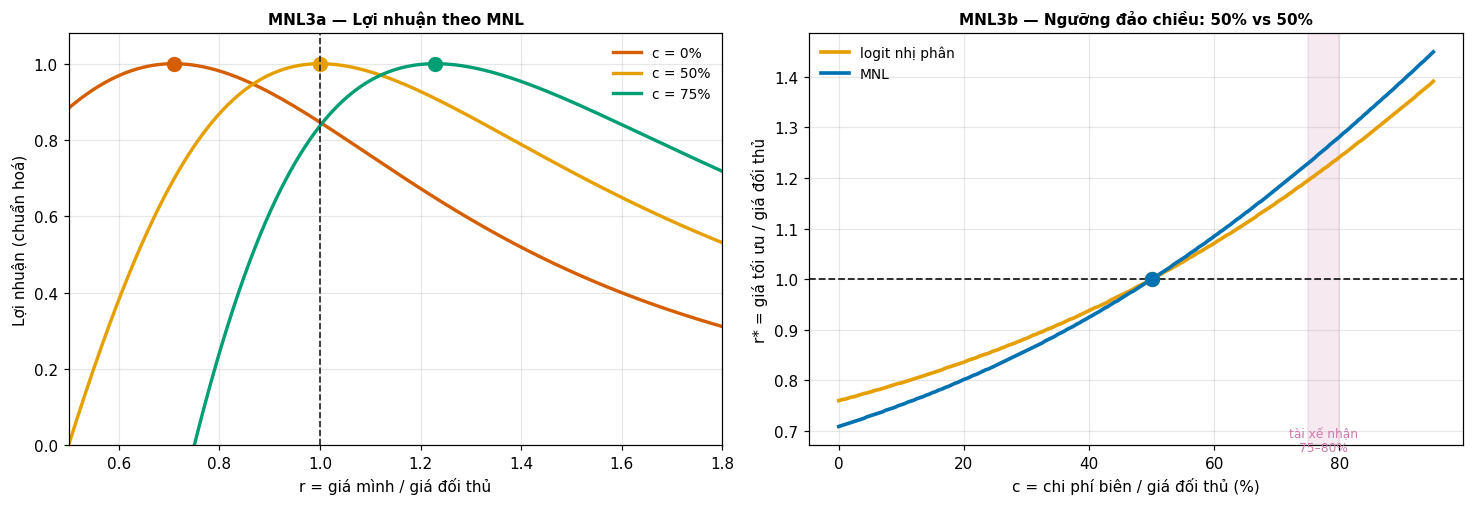

In [9]:
# ═════════ HINH MNL3 — gia toi uu ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))

for c, col in zip([0.0, 0.50, 0.75], [RED, ORANGE, GREEN]):
    v = (R_GRID - c) * mnl.share(R_GRID)
    ax[0].plot(R_GRID, v/v.max(), lw=2.2, color=col, label=f"c = {c:.0%}")
    k = int(np.argmax(v)); ax[0].plot(R_GRID[k], 1.0, "o", color=col, ms=9)
ax[0].axvline(1.0, color="#222", ls="--", lw=1.1)
ax[0].set_xlim(0.5, 1.8); ax[0].set_ylim(0, 1.08)
ax[0].set_xlabel("r = giá mình / giá đối thủ"); ax[0].set_ylabel("Lợi nhuận (chuẩn hoá)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("MNL3a — Lợi nhuận theo MNL", fontweight="bold", fontsize=10)

ax[1].plot(cs*100, rs_b, lw=2.4, color=ORANGE, label="logit nhị phân")
ax[1].plot(cs*100, rs_m, lw=2.4, color=BLUE, label="MNL")
ax[1].axhline(1.0, color="#222", ls="--", lw=1.2)
ax[1].axvspan(75, 80, color=PURPLE, alpha=.16)
ax[1].text(77.5, 0.66, "tài xế nhận\n75–80%", fontsize=8, color=PURPLE, ha="center")
ax[1].plot([c_bin*100], [1.0], "o", color=ORANGE, ms=9)
ax[1].plot([c_mnl*100], [1.0], "o", color=BLUE, ms=9)
ax[1].set_xlabel("c = chi phí biên / giá đối thủ (%)")
ax[1].set_ylabel("r* = giá tối ưu / giá đối thủ")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title(f"MNL3b — Ngưỡng đảo chiều: {c_bin:.0%} vs {c_mnl:.0%}",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MNL3_gia_toi_uu.png"); plt.show()

## 6. Kết luận

### ✅ GĐ 3 xong — và nó mở khoá GĐ 2.2

| Mục | Kết quả |
|---|---|
| **3.1** Cài đặt MNL 3 lựa chọn | ✅ lớp `MNL`, có `assert` kiểm chứng đạo hàm số |
| **3.2** Hiệu chỉnh `α₀` từ tỷ lệ không đi | ✅ qua `s₀` suy ngược |
| **3.3** Suy **cả 2** elasticity từ **một** `β` | ✅ kiểm chứng bằng đạo hàm số, sai lệch < 1e-3 |
| **3.4** Đối chiếu chéo với bằng chứng GMV | ✅ không mâu thuẫn |
| **3.5** So MNL vs logit nhị phân | ✅ xem bảng 3A |
| **2.2** Tỷ lệ không đi `s₀` | ✅ suy ngược được, nằm trong khoảng hợp lý |

### Giá trị thật của MNL ở đây

MNL **không cho kết luận mới** — nó cho **hai thứ khác**:

1. **Tính nhất quán bắt buộc.** Trong logit nhị phân, `ε_firm` và `ε_market` là hai con số rời rạc
   ta tự đặt, có thể mâu thuẫn nhau mà không biết. Trong MNL chúng bị **ràng buộc** bởi một `β`
   duy nhất — nếu đặt sai đôi, `s₀` sẽ nhả ra số vô lý ngay.
2. **`s₀` trở thành đại lượng đo được.** Thay vì hỏi mentor *"elasticity bao nhiêu"* (không ai biết),
   ta hỏi *"tỷ lệ khách xem giá rồi không đặt là bao nhiêu"* — **con số này team vận hành có sẵn**.

### ⚠️ Hạn chế

| Hạn chế | Ghi chú |
|---|---|
| Vẫn là **hiệu chỉnh**, không phải **ước lượng** | Không có dữ liệu lựa chọn để `.fit()` |
| Giả định **IIA** (Independence of Irrelevant Alternatives) | MNL chuẩn; nếu "mình" và "đối thủ" thay thế nhau mạnh hơn so với outside option thì cần Nested Logit |
| Thị phần `m` là giả định | Đã quét độ nhạy 20%–80% |
| Coi mình và đối thủ **cùng chất lượng** khi `m = 50%` | Chênh lệch chất lượng gộp vào `α₁ − α₂` |

### 📮 Câu hỏi mentor mà notebook này làm sắc hơn

| Câu hỏi cũ | Câu hỏi mới — **dễ trả lời hơn nhiều** |
|---|---|
| "Elasticity của khách là bao nhiêu?" | **"Bao nhiêu % khách xem giá rồi không đặt?"** (`s₀`) |
| — | **"Thị phần XanhSM so với đối thủ chính?"** (`m`) |

Có `s₀` và `m` là **chốt được `β`**, tức chốt được cả hai elasticity — không còn phải giả định.

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `MNL1_suy_nguoc_s0` | Bản đồ `s₀` theo 2 elasticity · độ nhạy theo thị phần |
| `MNL2_mnl_vs_logit` | MNL vs logit nhị phân — tuyệt đối và tương đối |
| `MNL3_gia_toi_uu` | Giá tối ưu theo MNL · ngưỡng đảo chiều 2 mô hình |

## Liên quan

| File | Vai trò |
|---|---|
| `00_TONG_HOP_chay_1_the.ipynb` | Logit nhị phân — notebook này kiểm chứng chéo nó |
| `07_chiphi_bien_va_uncertainty.ipynb` | Hàm mục tiêu lợi nhuận dùng lại ở Phần 5 |
| `09_doi_chieu_literature.ipynb` | GĐ 2.4 — đối chiếu dải elasticity với nghiên cứu đã công bố |